# 05 Knockout Analysis

This notebook follows the screenshot pattern:

- Build feature table and labels.
- Train a baseline model loss.
- Knock out one feature at a time and re-train.
- Rank loss impact in a bar chart.

Source inspiration: www.youtube.com/watch?v=5vsLmM756LA

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

root = Path.cwd()
sys.path.append(str(root / 'training'))
import nnue_lab_common as c

sns.set_theme(style='whitegrid')
device = c.device()
print('device:', device)

device: mps


In [5]:
def build_tabular(path, max_entries=70000, stride=12):
    rows = []
    with open(path, 'rb') as f:
        i = 0
        while len(rows) < max_entries:
            raw = f.read(c.ENTRY_SIZE)
            if not raw:
                break
            if i % stride == 0:
                p = c.parse_entry(raw)
                pc = p['piece_counts']
                rows.append([
                    pc[0], pc[1], pc[2], pc[3], pc[4],
                    pc[5], pc[6], pc[7], pc[8], pc[9],
                    p['stm'], p['pieces'],
                    len(p['white_feats']), len(p['black_feats']),
                ])
            i += 1
    labels = [
        '#pawns_w', '#knights_w', '#bishops_w', '#rooks_w', '#queens_w',
        '#pawns_b', '#knights_b', '#bishops_b', '#rooks_b', '#queens_b',
        'stm', '#pieces_total', '#white_feat', '#black_feat',
    ]
    X = pd.DataFrame(rows, columns=labels)

    mat = (
        3.4 * (X['#queens_w'] - X['#queens_b'])
        + 1.9 * (X['#rooks_w'] - X['#rooks_b'])
        + 1.2 * (X['#bishops_w'] - X['#bishops_b'])
        + 1.0 * (X['#knights_w'] - X['#knights_b'])
        + 0.23 * (X['#pawns_w'] - X['#pawns_b'])
    )
    phase = 0.12 * (X['#pieces_total'] - 20)
    activity = 0.05 * (X['#white_feat'] - X['#black_feat'])
    stm_term = np.where(X['stm'] > 0, -0.35, 0.35)
    y_series = np.clip(mat + phase + activity + stm_term + np.random.normal(0.0, 1.4, size=len(X)), -22, 22)
    y = np.asarray(y_series, dtype=np.float32)
    return X, y, labels

X_raw, y, LABELS = build_tabular(c.default_training_file())
split = int(0.2 * len(X_raw))
X_test_raw = X_raw.iloc[:split].copy()
X_train_raw = X_raw.iloc[split:].copy()
y_test = y[:split]
y_train = y[split:]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0).replace(0, 1.0)
X_train_full = ((X_train_raw - mu) / sigma).to_numpy(dtype=np.float32)
X_test_full = ((X_test_raw - mu) / sigma).to_numpy(dtype=np.float32)

class KnockNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.LeakyReLU(),
            nn.Linear(32, 16), nn.LeakyReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_eval(Xtr, ytr, Xte, yte, epochs=4):
    model = KnockNet(Xtr.shape[1]).to(device)
    opt = optim.Adam(model.parameters(), lr=2e-3)
    criterion = nn.HuberLoss(delta=1.0)

    Xt = torch.tensor(Xtr, device=device)
    yt = torch.tensor(ytr[:, None], device=device)
    model.train()
    for _ in range(epochs):
        order = torch.randperm(Xt.size(0), device=device)
        for start in range(0, Xt.size(0), 1024):
            idx = order[start:start + 1024]
            xb = Xt[idx]
            yb = yt[idx]
            pred = model(xb)
            loss = criterion(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(Xte, device=device)).squeeze(1).cpu().numpy()
    return float(np.mean(np.abs(pred - yte)))

baseline_loss = train_eval(X_train_full, y_train, X_test_full, y_test, epochs=4)
auto_results = [(-1, baseline_loss)]

for i, feat in enumerate(LABELS):
    keep = [j for j in range(len(LABELS)) if j != i]
    loss = train_eval(X_train_full[:, keep], y_train, X_test_full[:, keep], y_test, epochs=4)
    auto_results.append((i, loss))

knockout_results = pd.DataFrame({
    'Feature': [LABELS[i] if i >= 0 else 'None (all)' for i, _ in auto_results],
    'Loss': [l for _, l in auto_results],
})
knockout_results['Loss Delta'] = knockout_results['Loss'] - baseline_loss

display(knockout_results.sort_values('Loss Delta', ascending=False))

,Feature,Loss,Loss Delta
5,#queens_w,1.237255,0.109815
10,#queens_b,1.226405,0.098966
4,#rooks_w,1.202593,0.075154
9,#rooks_b,1.178350,0.050910
8,#bishops_b,1.166524,0.039085
2,#knights_w,1.162302,0.034863
3,#bishops_w,1.158955,0.031515
11,stm,1.158523,0.031084
7,#knights_b,1.147848,0.020409
1,#pawns_w,1.131331,0.003891


,Feature,Loss,Loss Delta
5,#queens_w,1.237255,0.109815
10,#queens_b,1.226405,0.098966
4,#rooks_w,1.202593,0.075154
9,#rooks_b,1.178350,0.050910
8,#bishops_b,1.166524,0.039085
2,#knights_w,1.162302,0.034863
3,#bishops_w,1.158955,0.031515
11,stm,1.158523,0.031084
7,#knights_b,1.147848,0.020409
1,#pawns_w,1.131331,0.003891


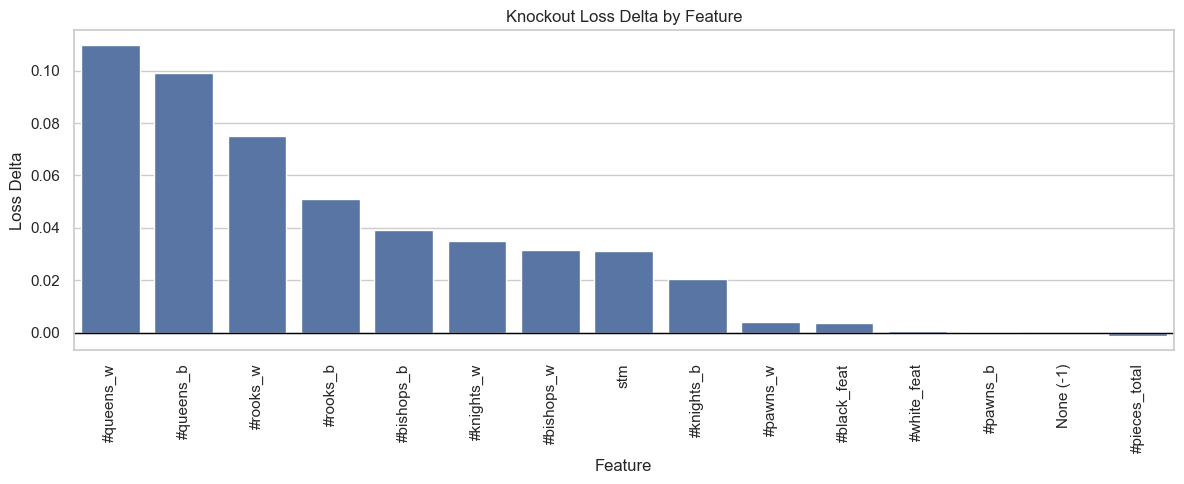

In [6]:
feature_data = pd.DataFrame({
    'Feature': [LABELS[i] if i >= 0 else 'None (-1)' for i, _ in auto_results],
    'Loss': [l for _, l in auto_results],
})
feature_data['Loss Delta'] = feature_data['Loss'] - feature_data.loc[feature_data['Feature'] == 'None (-1)', 'Loss'].iloc[0]
plot_df = feature_data.sort_values('Loss Delta', ascending=False)

display(plot_df)

plt.figure(figsize=(12, 5))
sns.barplot(x='Feature', y='Loss Delta', data=plot_df)
plt.axhline(0.0, color='black', linewidth=1)
# plt.yscale('log')
plt.xticks(rotation=90)
plt.title('Knockout Loss Delta by Feature')
plt.tight_layout()
plt.show()